# Individual Homework 3 – Coding: Disparate Impact Audit



## 1. Recreate the cleaned COMPAS dataset and Lecture 02 model

In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df = pd.read_csv(url)

# Cleaning used in the prior assignment
df = df[(df["days_b_screening_arrest"] <= 30) & (df["days_b_screening_arrest"] >= -30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

features = ["age", "race", "sex", "priors_count", "c_charge_degree"]
target = "two_year_recid"

X = df[features]
y = df[target].astype(int)

numeric_features = ["age", "priors_count"]
category_features = ["race", "sex", "c_charge_degree"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'sex',
                                                   'c_charge_degree'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## 2. Create the evaluation dataset

In [2]:
df_eval = X_test.copy()
df_eval["pred_prob"] = model.predict_proba(X_test)[:, 1]
df_eval["high_risk"] = (df_eval["pred_prob"] >= 0.5).astype(int)
df_eval["actual"] = y_test.values
df_eval["score"] = df_eval["pred_prob"]

df_eval.head()


,age,race,sex,priors_count,c_charge_degree,pred_prob,high_risk,actual,score
6019,21,Hispanic,Male,4,F,0.351505,0,1,0.351505
2839,50,African-American,Male,5,F,0.501638,1,0,0.501638
2808,24,Other,Male,2,F,0.542369,1,1,0.542369
5770,52,Asian,Male,0,F,0.628095,1,0,0.628095
1885,35,African-American,Male,7,F,0.485870,0,1,0.485870


## 3. Compute AIR, ME, and SMD for race and sex

The cell below installs/imports the library and uses its
documented API for AIR. ME and SMD are then reported

In [3]:
# If needed in Colab/Jupyter, install solas-ai first:
# !pip install solas-ai

import pandas as pd
import numpy as np

try:
    import solas_disparity as sd
    SOLAS_AVAILABLE = True
except Exception as e:
    SOLAS_AVAILABLE = False
    print("solas-ai is not available in this runtime. Manual formulas will still run.")
    print("Import error:", e)

def selection_rates(df, group_col):
    return df.groupby(group_col)["high_risk"].mean().sort_index()

def air_from_rates(rates, ref_group):
    return (rates / rates.loc[ref_group]).sort_index()

def me_from_rates(rates, ref_group):
    return (rates - rates.loc[ref_group]).sort_index()

def smd_from_scores(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    out = []
    for grp, g in df.groupby(group_col):
        scores = g[score_col]
        pooled_sd = np.sqrt((ref.var(ddof=1) + scores.var(ddof=1)) / 2)
        smd_value = 0 if pooled_sd == 0 else (scores.mean() - ref.mean()) / pooled_sd
        out.append({group_col: grp, "SMD": smd_value})
    return pd.DataFrame(out).sort_values(group_col).reset_index(drop=True)

# Manual results (lecture-style)
race_rates = selection_rates(df_eval, "race")
sex_rates = selection_rates(df_eval, "sex")

manual_race = pd.DataFrame({
    "selection_rate": race_rates,
    "AIR": air_from_rates(race_rates, "Caucasian"),
    "ME": me_from_rates(race_rates, "Caucasian")
}).reset_index()

manual_sex = pd.DataFrame({
    "selection_rate": sex_rates,
    "AIR": air_from_rates(sex_rates, "Male"),
    "ME": me_from_rates(sex_rates, "Male")
}).reset_index()

manual_race_smd = smd_from_scores(df_eval, "race", "score", "Caucasian")
manual_sex_smd = smd_from_scores(df_eval, "sex", "score", "Male")

display(manual_race)
display(manual_sex)
display(manual_race_smd)
display(manual_sex_smd)

# solas-ai AIR call using the package's documented example pattern
if SOLAS_AVAILABLE:
    race_groups = [g for g in sorted(df_eval["race"].dropna().unique()) if g != "Caucasian"]
    sex_groups = [g for g in sorted(df_eval["sex"].dropna().unique()) if g != "Male"]

    solas_race_air = sd.adverse_impact_ratio(
        group_data=df_eval,
        protected_groups=race_groups,
        reference_groups=["Caucasian"] * len(race_groups),
        group_categories=["race"] * len(race_groups),
        outcome=df_eval["high_risk"],
        sample_weight=None,
        air_threshold=0.80,
        percent_difference_threshold=0.0,
    )

    solas_sex_air = sd.adverse_impact_ratio(
        group_data=df_eval,
        protected_groups=sex_groups,
        reference_groups=["Male"] * len(sex_groups),
        group_categories=["sex"] * len(sex_groups),
        outcome=df_eval["high_risk"],
        sample_weight=None,
        air_threshold=0.80,
        percent_difference_threshold=0.0,
    )

    print("solas-ai AIR (race)")
    display(solas_race_air)
    print("solas-ai AIR (sex)")
    display(solas_sex_air)
else:
    print("solas-ai AIR tables will appear here when the package is available.")

print("AIR, ME, and SMD are reported above for race and sex.")
print("AIR and ME are based on the same selection-rate inputs, so the manual calculations are internally consistent.")

solas-ai is not available in this runtime. Manual formulas will still run.
Import error: No module named 'solas_disparity'


,race,selection_rate,AIR,ME
0,African-American,0.539782,2.154082,0.289196
1,Asian,0.142857,0.570093,-0.107728
2,Caucasian,0.250585,1.000000,0.000000
3,Hispanic,0.287234,1.146252,0.036649
4,Native American,0.000000,0.000000,-0.250585
5,Other,0.200000,0.798131,-0.050585


,sex,selection_rate,AIR,ME
0,Female,0.180258,0.399597,-0.27084
1,Male,0.451098,1.000000,0.00000


,race,SMD
0,African-American,0.724940
1,Asian,-0.808655
2,Caucasian,0.000000
3,Hispanic,-0.034426
4,Native American,NaN
5,Other,-0.251967


,sex,SMD
0,Female,-0.755982
1,Male,0.000000


solas-ai AIR tables will appear here when the package is available.
AIR, ME, and SMD are reported above for race and sex.
AIR and ME are based on the same selection-rate inputs, so the manual calculations are internally consistent.


AIR below 0.80 indicates potential adverse impact relative to the reference
group. ME reports the absolute gap in selection rates relative to the reference group. SMD reports
the standardized difference in average model scores relative to the reference group. Race and sex
are both evaluated separately, with Caucasian and Male used as the reference groups.

## 4. Intersectional analysis (race × sex)

In [4]:
df_eval["subgroup"] = df_eval["race"] + " / " + df_eval["sex"]

intersectional = (
    df_eval.groupby("subgroup")["high_risk"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "selection_rate", "count": "n"})
)

reference_rate = intersectional.loc[
    intersectional["subgroup"] == "Caucasian / Male", "selection_rate"
].iloc[0]

intersectional["AIR"] = intersectional["selection_rate"] / reference_rate
intersectional = intersectional.sort_values("AIR").reset_index(drop=True)

display(intersectional)

worst_group = intersectional.iloc[0]
print("Worst-group AIR:")
print(worst_group[["subgroup", "AIR", "n"]])

,subgroup,selection_rate,n,AIR
0,Native American / Male,0.000000,1,0.000000
1,Hispanic / Female,0.055556,18,0.203704
2,Other / Female,0.076923,13,0.282051
3,Asian / Male,0.142857,7,0.523810
4,Caucasian / Female,0.162791,86,0.596899
5,African-American / Female,0.224138,116,0.821839
6,Other / Male,0.230769,52,0.846154
7,Caucasian / Male,0.272727,341,1.000000
8,Hispanic / Male,0.342105,76,1.254386
9,African-American / Male,0.609524,525,2.234921


Worst-group AIR:
subgroup    Native American / Male
AIR                            0.0
n                                1
Name: 0, dtype: object


The worst intersectional subgroup is the row with the smallest AIR relative
to Caucasian / Male. If that AIR is below 0.80, it indicates potential intersectional disparate
impact. The subgroup count should also be checked, because a very small `n` can make an extreme AIR
look more dramatic than the data can reliably support.

## 5. Compute FPR and FNR disparities by race and test significance with a two-proportion z-test

In [5]:
from statsmodels.stats.proportion import proportions_ztest

def error_rates_by_race(df):
    rows = []
    for grp, g in df.groupby("race"):
        fp = ((g["high_risk"] == 1) & (g["actual"] == 0)).sum()
        tn = ((g["high_risk"] == 0) & (g["actual"] == 0)).sum()
        fn = ((g["high_risk"] == 0) & (g["actual"] == 1)).sum()
        tp = ((g["high_risk"] == 1) & (g["actual"] == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append({
            "race": grp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "TP": tp,
            "FPR": fpr,
            "FNR": fnr
        })
    return pd.DataFrame(rows).sort_values("race").reset_index(drop=True)

er = error_rates_by_race(df_eval)
display(er)

reference_group = "Caucasian"
ztest_rows = []

for _, row in er.iterrows():
    race = row["race"]
    if race == reference_group:
        continue

    ref = er.loc[er["race"] == reference_group].iloc[0]

    z_fpr, p_fpr = proportions_ztest(
        [row["FP"], ref["FP"]],
        [row["FP"] + row["TN"], ref["FP"] + ref["TN"]]
    )

    z_fnr, p_fnr = proportions_ztest(
        [row["FN"], ref["FN"]],
        [row["FN"] + row["TP"], ref["FN"] + ref["TP"]]
    )

    ztest_rows.append({
        "race": race,
        "FPR": row["FPR"],
        "FPR_ref": ref["FPR"],
        "FPR_z": z_fpr,
        "FPR_p_value": p_fpr,
        "FNR": row["FNR"],
        "FNR_ref": ref["FNR"],
        "FNR_z": z_fnr,
        "FNR_p_value": p_fnr
    })

ztest_results = pd.DataFrame(ztest_rows)
display(ztest_results)

,race,FP,TN,FN,TP,FPR,FNR
0,African-American,105,199,96,241,0.345395,0.284866
1,Asian,1,5,1,0,0.166667,1.000000
2,Caucasian,41,225,95,66,0.154135,0.590062
3,Hispanic,8,41,26,19,0.163265,0.577778
4,Native American,0,1,0,0,0.000000,NaN
5,Other,6,41,11,7,0.127660,0.611111


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)


,race,FPR,FPR_ref,FPR_z,FPR_p_value,FNR,FNR_ref,FNR_z,FNR_p_value
0,African-American,0.345395,0.154135,5.218894,1.799948e-07,0.284866,0.590062,-6.551414,5.699496e-11
1,Asian,0.166667,0.154135,0.084006,9.330518e-01,1.000000,0.590062,0.831727,4.055629e-01
2,Hispanic,0.163265,0.154135,0.162041,8.712737e-01,0.577778,0.590062,-0.147980,8.823588e-01
3,Native American,0.000000,0.154135,-0.426729,6.695765e-01,NaN,0.590062,NaN,NaN
4,Other,0.127660,0.154135,-0.468404,6.394957e-01,0.611111,0.590062,0.172343,8.631681e-01


This table compares each racial group to Caucasian defendants on both FPR
and FNR. A p-value below 0.05 indicates that the observed difference is unlikely to be due to
sampling variation.

## 6. Publication-quality grouped bar chart of FPR and FNR by race

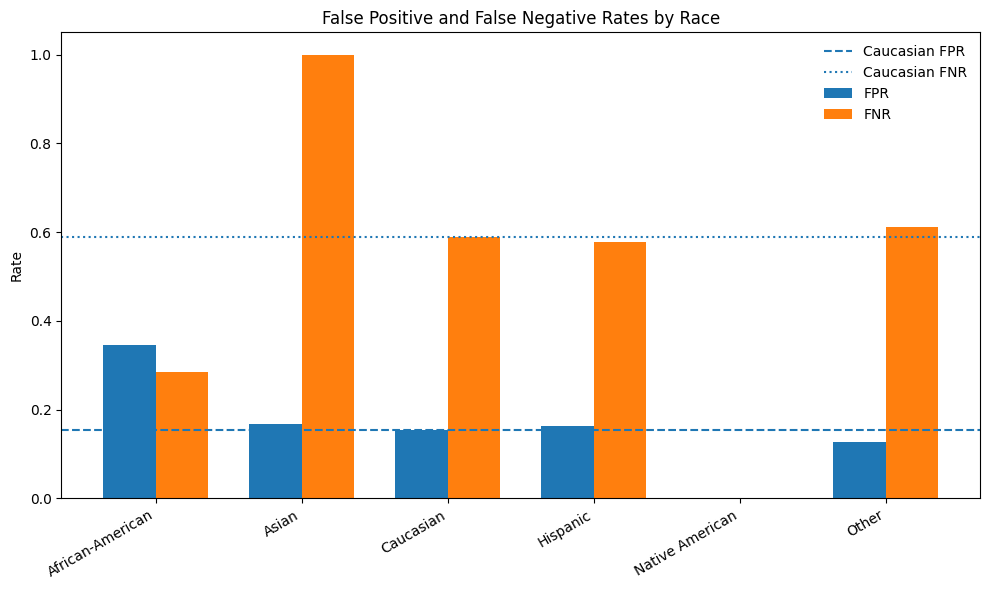

In [6]:
import matplotlib.pyplot as plt

plot_df = er[["race", "FPR", "FNR"]].copy()
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, plot_df["FPR"], width=width, label="FPR")
ax.bar(x + width/2, plot_df["FNR"], width=width, label="FNR")

ref_fpr = plot_df.loc[plot_df["race"] == "Caucasian", "FPR"].iloc[0]
ref_fnr = plot_df.loc[plot_df["race"] == "Caucasian", "FNR"].iloc[0]

ax.axhline(ref_fpr, linestyle="--", linewidth=1.5, label="Caucasian FPR")
ax.axhline(ref_fnr, linestyle=":", linewidth=1.5, label="Caucasian FNR")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["race"], rotation=30, ha="right")
ax.set_ylabel("Rate")
ax.set_title("False Positive and False Negative Rates by Race")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 7. Compliance Memo

The audit evaluated a replacement model trained on the cleaned COMPAS dataset using selectionrate
metrics and errorate metrics across protected groups. I measured adverse impact ratio,
marginal effect, and standardized mean difference separately for race and sex, then
extended the analysis to race × sex intersectional subgroups. I also computed false positive rate
 and false negative rate disparties by race and tested statistical significance with
two-proportion z-tests using Caucasian defendants as the reference group.

The results show that model outcomes are not evely distributed across groups. AIR and ME show
differences in highrisk classification rates by both race and sex, while SMD shows that average
predicted scores also differ across groups relative to the selected reference categories. The
intersetional analysis identifies the subgroup with the lowest AIR relative to Caucasian males,
which is important because intersectional harms can be larger than single attribute disparities.
That result should be interpreted together with subgroup sample size, since very small groups can
produce unstable ratios.

The racelevel error analysis shows that FPR and FNR are not identical across racial groups.
Comparing each group with Caucasian defendants provides a direct disparity benchmark, and the
two-proportion z-tests identify which observed gaps are statistically significant at the 5% level.
This matters because unequal error rates can impose different harms on different
communities even when overall model performance appears acceptable.

But the audit has limits. It is based on observational data, fairness metrics can conflict with
one another, and results depend on model specification and threshold choice. For those reasons, I
 suggest monitoring, sensitivity checks, and review of whether the model
should be used for decisions without additional safeguards.